In [7]:
import pandas as pd
import tomllib
import numpy as np
import statistics

from pathlib import Path
from startorch import PROJECT_ROOT, load_config, load_benchmark_config

CONFIG_PATH = PROJECT_ROOT / "python" / "benchmark" / "benchmark-config.toml"

config = load_config()
benchmark_config = load_benchmark_config()
print(config)

{'data-path': {'upstream-path': 'data/parquet', 'data-path': '/data/scholar_rank/data', 'posting-path': '/data/scholar_rank/posting', 'tmp-corpus-folder': 'tmp', 'full-corpus-folder': 'full_corpus', 'works-subset-folder': 'works_subset'}, 'works-subset': {'subset-profiles': {'math-en': "topics[1].field_display_name = 'Mathematics' AND language = 'en'", 'engr-en': "topics[1].field_display_name = 'Engineering' AND language = 'en'", 'vet-en': "topics[1].field_display_name = 'Veterinary' AND language = 'en'", 'cs-en': "topics[1].field_display_name = 'Computer Science' AND language = 'en'", 'full-en': "language = 'en'", 'full-en-2': "language = 'en'"}}, 'duckdb': {'spill-path': '/data/scholar_rank/data/spill'}, 'posting': {'lookup-folder': 'lookup', 'lookup-file-name': 'doc_id_lookup.bin', 'token-stream-folder': 'token_stream', 'posting-folder': 'posting', 'partial-folder': 'posting/partial'}}


In [14]:
collection = pd.read_csv(
    Path(benchmark_config["msmarco"]["data-dir"]) / "collection.tsv",
    sep='\t',
    header=None,
    names=["pid", "passage"],
)
print(collection.head())

   pid                                            passage
0    0  The presence of communication amid scientific ...
1    1  The Manhattan Project and its atomic bomb help...
2    2  Essay on The Manhattan Project - The Manhattan...
3    3  The Manhattan Project was the name for a proje...
4    4  versions of each volume as well as complementa...


In [15]:
queries = pd.read_csv(
    Path(benchmark_config["msmarco"]["data-dir"]) / "queries.dev.small.tsv",
    sep='\t',
    header=None,
    names=["qid", "query"]
)
print(queries.head())
queries.shape

       qid                                          query
0  1048585                   what is paula deen's brother
1        2                       Androgen receptor define
2   524332  treating tension headaches without medication
3  1048642                            what is paranoid sc
4   524447            treatment of varicose veins in legs


(6980, 2)

In [16]:
qrels = pd.read_csv(
    Path(benchmark_config["msmarco"]["data-dir"]) / "qrels.dev.small.tsv",
    sep='\t',
    header=None,
    names=["qid", "unused", "pid", "relevance"]
)
print(qrels.head(10))

       qid  unused      pid  relevance
0   300674       0  7067032          1
1   125705       0  7067056          1
2    94798       0  7067181          1
3     9083       0  7067274          1
4   174249       0  7067348          1
5   320792       0  7067677          1
6  1090270       0  7067796          1
7  1101279       0  7067891          1
8   201376       0  7068066          1
9    54544       0  7068203          1


In [26]:
query_result_dir = Path(benchmark_config["msmarco"]["posting-dir"]) / "query_result"
print (query_result_dir)
perf_path = query_result_dir / "perf_raw.parquet"

perf = pd.read_parquet(
    perf_path,
)
perf = perf.drop(perf[perf["run_name"] == "queries.dev.tsv"].index)

print(perf.columns)
perf["max_rss"] = perf["max_rss"].astype(float).apply(lambda x: x/1024)
perf["query_latency_mean"] = perf['query_latency'].apply(lambda x: sum(x) / len(x) if len(x) > 0 else 0)
perf["query_latency_median"] = perf['query_latency'].apply(statistics.median)
perf["query_latency_p95"] = perf['query_latency'].apply(lambda x: np.percentile(x,95))
perf["query_latency_p99"] = perf['query_latency'].apply(lambda x: np.percentile(x,99))
perf["query_latency_max"] = perf['query_latency'].apply(lambda x: np.max(x))
perf["query_latency_min"] = perf['query_latency'].apply(lambda x: np.min(x))
df = perf[["run_name", "query_latency_mean", "query_latency_median", "query_latency_p95", "query_latency_p99", "query_latency_max", "query_latency_min", "engine_latency", "max_rss"]]
print(df)

/data/scholar_rank/benchmark/msmarco/query_result
Index(['run_name', 'query_latency', 'engine_latency', 'max_rss'], dtype='str')
                run_name  query_latency_mean  query_latency_median  \
0  queries.dev.small.tsv           16.020343               10.6445   

   query_latency_p95  query_latency_p99  query_latency_max  query_latency_min  \
0           47.20125           85.46484            388.862              0.009   

   engine_latency      max_rss  
0        3061.471  1777.941406  


In [4]:
full_meta_path = Path(config["data-path"]["posting-path"]) / "full_en" / config["posting"]["posting-folder"] / "metadata.bin"
query_data_dir = Path(benchmark_config["paths"]["data-dir"]) / "full-en"

random = pd.read_csv(query_data_dir / "random_set.tsv", sep="\t", header=None)
common = pd.read_csv(query_data_dir / "common_set.tsv", sep="\t", header=None)
very_common = pd.read_csv(query_data_dir / "very_common_set.tsv", sep="\t",header=None)
rare = pd.read_csv(query_data_dir / "rare_set.tsv", sep="\t",header=None)
skewed = pd.read_csv(query_data_dir / "skewed_set.tsv", sep="\t",header=None)

In [29]:
print(random.head())
print(random.shape)


   0                                                  1
0  0           5130195 sh129436 7013924 mddifi 10281684
1  1  349485 01eo00063 10154260 6393953 sh1002589 me...
2  2  homoprotoberberin hld6 1932011501 trekfont hen...
3  3  kalaninuiohilaukapu holloston implantattab 170...
4  4  nanimono br0000020280512 dewsweep repraes 9749...
(1000, 2)


In [11]:
print(common.head())

   0 fairshar boucek peekskil benzoxadiazol carpobrotus
0  1  183004 4801 164236 169134 kkn loigolactobacill...
1  2  sealift apollo 159100 tranylcypromin varphi an...
2  3  assistantship canariensi arthropoda 145613 925...
3  4  maxillaria 175974 136926 119319 174636 maxim 1...
4  5  nucellar 113138 desultori 144613 150707 aljaz ...


In [12]:
print(very_common.head())

   0              detector approxim william eros peptid
0  1  scholarship hydrolysi hepatolog arteri scienti...
1  2  logist brain annot neurobiolog petroleum clust...
2  3          payment jpg interferometri chronic attenu
3  4  data pipelin gyrotron upper literatur gamma tr...
4  5                  past guidelin opinion hiv languag


In [13]:
print(rare.head())

   0     03zagreb1298 11001672 zynck 10794357 sh0040680
0  1  sh305855 sacomplet 2801919 10138253 sh1650397 ...
1  2  10060963 98614fd0 tarifnaia 613563 10715129 14...
2  3  bawnag 10230804 00091348 roedoff 4674078 86454...
3  4  7258599 10875846 1146952 5947480 10716221 fbai...
4  5  6388982 5752683 1133169 ssk41951 apertureradiomet


In [14]:
print(skewed.head())

   0        black snubberu 10818637 digubl835 rangeland
0  1  10371029 532249 june electrolyt probabl assemb...
1  2  induct discoveri hear 10425296 10393929 linnae...
2  3            4835884 10096231 tecton pandem 10868209
3  4  treatment 6885129 demand 10370854 influenc 001...
4  5                  9033930 8937349 8378978 21 servic


In [8]:
pd.set_option('display.max_columns', None)
query_result_dir = Path(benchmark_config["paths"]["benchmark-dir"]) / "full-en" / "query_result"
print(query_result_dir)
perf_path = query_result_dir / "perf_raw.parquet"

perf = pd.read_parquet(
    perf_path,
)

print(perf.columns)
perf["max_rss"] = perf["max_rss"].astype(float).apply(lambda x: x/1024)
perf["query_latency_mean"] = perf['query_latency'].apply(lambda x: sum(x) / len(x) if len(x) > 0 else 0)
perf["query_latency_median"] = perf['query_latency'].apply(statistics.median)
perf["query_latency_p95"] = perf['query_latency'].apply(lambda x: np.percentile(x,95))
perf["query_latency_p99"] = perf['query_latency'].apply(lambda x: np.percentile(x,99))
perf["query_latency_max"] = perf['query_latency'].apply(lambda x: np.max(x))
perf["query_latency_min"] = perf['query_latency'].apply(lambda x: np.min(x))
df = perf[[
    "run_name", "query_latency_mean", "query_latency_median", "query_latency_p95", "query_latency_p99",
    "query_latency_max", "query_latency_min", "max_rss"]]
print(df)
mx = perf["engine_latency"].max()
mn = perf["engine_latency"].min()
print(mx, mn)

/data/scholar_rank/benchmark/full-en/query_result
Index(['run_name', 'query_latency', 'engine_latency', 'max_rss'], dtype='str')
                               run_name  query_latency_mean  \
0                     random_set.tsv_10            1.983297   
1                   random_set.tsv_1000            0.596992   
2                     common_set.tsv_10            5.149727   
3                   common_set.tsv_1000           11.289559   
4                very_common_set.tsv_10         1013.874677   
5              very_common_set.tsv_1000         1291.941447   
6                       rare_set.tsv_10            1.237838   
7                     rare_set.tsv_1000            0.133457   
8                     skewed_set.tsv_10          333.689160   
9                   skewed_set.tsv_1000          504.892959   
10         random_set.tsv_10_exhaustive            3.098438   
11       random_set.tsv_1000_exhaustive            0.868369   
12         common_set.tsv_10_exhaustive           48

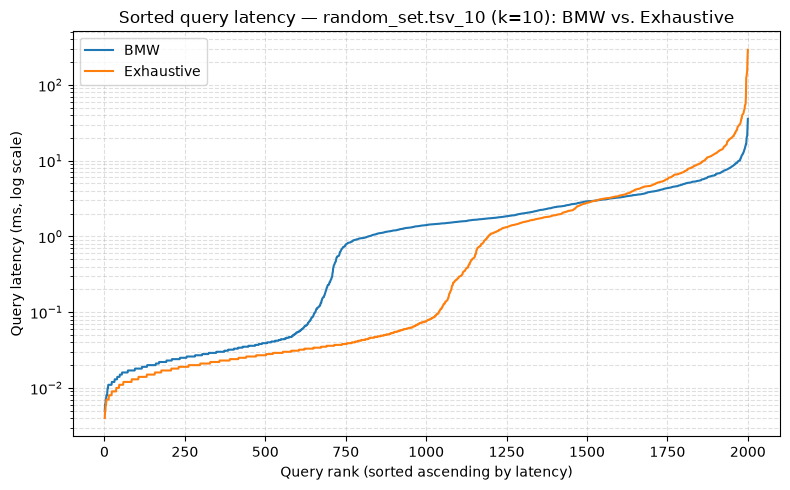

In [ ]:
import matplotlib.pyplot as plt

bmw_latency = np.sort(perf.loc[perf["run_name"] == "random_set.tsv_10", "query_latency"].iloc[0])
exhaustive_latency = np.sort(perf.loc[perf["run_name"] == "random_set.tsv_10_exhaustive", "query_latency"].iloc[0])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1, len(bmw_latency) + 1), bmw_latency, label="BMW", linewidth=1.5)
ax.plot(np.arange(1, len(exhaustive_latency) + 1), exhaustive_latency, label="Exhaustive", linewidth=1.5)
ax.set_yscale("log")
ax.set_xlabel("Query rank (sorted ascending by latency)")
ax.set_ylabel("Query latency (ms, log scale)")
ax.set_title("Sorted query latency — random_set (k=10): BMW vs. Exhaustive")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

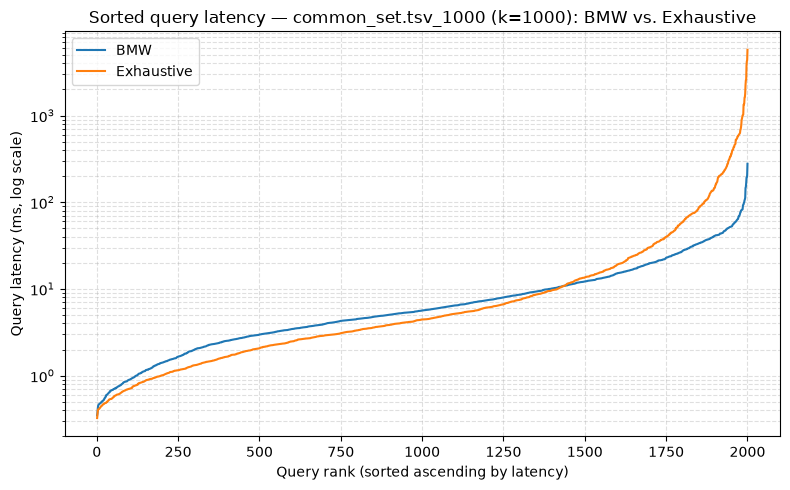

In [ ]:
bmw_latency = np.sort(perf.loc[perf["run_name"] == "common_set.tsv_1000", "query_latency"].iloc[0])
exhaustive_latency = np.sort(perf.loc[perf["run_name"] == "common_set.tsv_1000_exhaustive", "query_latency"].iloc[0])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1, len(bmw_latency) + 1), bmw_latency, label="BMW", linewidth=1.5)
ax.plot(np.arange(1, len(exhaustive_latency) + 1), exhaustive_latency, label="Exhaustive", linewidth=1.5)
ax.set_yscale("log")
ax.set_xlabel("Query rank (sorted ascending by latency)")
ax.set_ylabel("Query latency (ms, log scale)")
ax.set_title("Sorted query latency — common_set (k=1000): BMW vs. Exhaustive")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

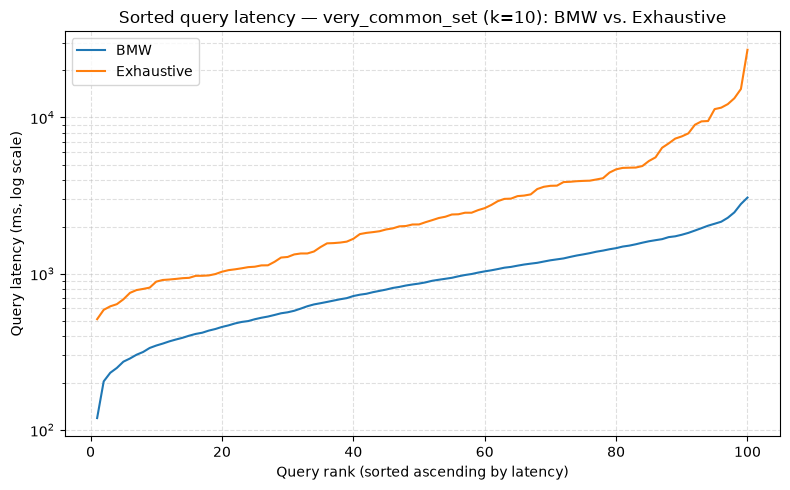

In [9]:
bmw_latency = np.sort(perf.loc[perf["run_name"] == "very_common_set.tsv_10", "query_latency"].iloc[0])[::20]
exhaustive_latency = np.sort(perf.loc[perf["run_name"] == "very_common_set.tsv_10_exhaustive", "query_latency"].iloc[0])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1, len(bmw_latency) + 1), bmw_latency, label="BMW", linewidth=1.5)
ax.plot(np.arange(1, len(exhaustive_latency) + 1), exhaustive_latency, label="Exhaustive", linewidth=1.5)
ax.set_yscale("log")
ax.set_xlabel("Query rank (sorted ascending by latency)")
ax.set_ylabel("Query latency (ms, log scale)")
ax.set_title("Sorted query latency — very_common_set (k=10): BMW vs. Exhaustive")
ax.legend()
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [21]:
pd.set_option('display.max_columns', None)
query_result_dir = Path(benchmark_config["paths"]["benchmark-dir"]) / "full-en" / "query_result"
print(query_result_dir)
correctness_path = query_result_dir / "correctness_raw.parquet"

correctness = pd.read_parquet(
    correctness_path,
)

bmw_min = pd.to_numeric(correctness["bmw_min_score"], errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
exhaustive_min = pd.to_numeric(correctness["exhaustive_min_score"], errors="coerce").to_numpy(dtype="float64", na_value=np.nan)

bmw_max = pd.to_numeric(correctness["bmw_max_score"], errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
exhaustive_max = pd.to_numeric(correctness["exhaustive_max_score"], errors="coerce").to_numpy(dtype="float64", na_value=np.nan)

TOL = 1e-6

correctness["min_matches"] = np.isclose(bmw_min, exhaustive_min, rtol=0, atol=TOL, equal_nan=True)
correctness["max_matches"] = np.isclose(bmw_max, exhaustive_max, rtol=0, atol=TOL, equal_nan=True)

correctness["sum_missing"] = correctness["missing_docids"].apply(lambda per_query: sum(len(q) for q in per_query))
correctness["sum_extra"] = correctness["extra_docids"].apply(lambda per_query: sum(len(q) for q in per_query))

# correctness["sum_missing"] = correctness["missing_docids"].str.len().sum()
# correctness["sum_extra"] = correctness["extra_docids"].str.len().sum()

print(correctness.head())

print(correctness.columns)
print(correctness[["run_name", "query_matches", "min_matches", "max_matches", "sum_missing", "sum_extra"]])

/data/scholar_rank/benchmark/full-en/query_result
                       run_name  \
0      random_set.tsv_1000_2000   
1      common_set.tsv_1000_2000   
2  very_common_set.tsv_1000_100   
3       skewed_set.tsv_1000_100   
4        rare_set.tsv_1000_2000   

                                        rank_matches  query_matches  \
0  [True, True, True, True, True, True, True, Tru...           2000   
1  [True, True, True, True, True, True, True, Tru...           1999   
2  [True, True, False, True, True, True, True, Tr...             70   
3  [True, True, True, True, False, True, True, Tr...             93   
4  [True, True, True, True, True, True, True, Tru...           2000   

                                      missing_docids  \
0  [[], [], [], [], [], [], [], [], [], [], [], [...   
1  [[], [], [], [], [], [], [], [], [], [], [], [...   
2  [[], [], [], [], [], [], [], [], [], [], [], [...   
3  [[], [], [], [], [], [], [], [], [], [], [], [...   
4  [[], [], [], [], [], [], [], 